In [2]:
import pandas as pd

In [3]:
sous_alim = pd.read_csv(r"C:\Users\nasso\Downloads\fao-6a6b22faa98d4066102032\FAO\fr_sousalimentation.csv")

In [4]:
sous_alim

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,7.9,F,Estimation FAO,NaN
1,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,8.8,F,Estimation FAO,NaN
2,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,9.6,F,Estimation FAO,NaN
3,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,10.2,F,Estimation FAO,NaN
4,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20162018,2016-2018,millions,10.6,F,Estimation FAO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,6.6,F,Estimation FAO,NaN
1016,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,7.2,F,Estimation FAO,NaN
1017,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,7.8,F,Estimation FAO,NaN
1018,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,8.2,F,Estimation FAO,NaN


In [5]:
print(sous_alim.shape)
print(sous_alim["Année"].unique())
print(sous_alim["Valeur"].isna().sum(), "/", len(sous_alim))

(1020, 15)
['2012-2014' '2013-2015' '2014-2016' '2015-2017' '2016-2018']
415 / 1020


In [6]:
pd.crosstab(sous_alim["Année"], sous_alim["Valeur"].isna())

Valeur,False,True
Année,,
2012-2014,120,84
2013-2015,120,84
2014-2016,121,83
2015-2017,122,82
2016-2018,122,82


In [7]:
anim = pd.read_csv(r"C:\Users\nasso\Downloads\fao-6a6b22faa98d4066102032\FAO\fr_animaux.csv")
cer =  pd.read_csv(r"C:\Users\nasso\Downloads\fao-6a6b22faa98d4066102032\FAO\fr_céréales.csv")
popu = pd.read_csv(r"C:\Users\nasso\Downloads\fao-6a6b22faa98d4066102032\FAO\fr_population.csv")
vege = pd.read_csv(r"C:\Users\nasso\Downloads\fao-6a6b22faa98d4066102032\FAO\fr_vegetaux.csv")
print("Sous-alimentation :", sous_alim["Zone"].nunique())
print("Animaux           :", anim["Zone"].nunique())
print("Céréales          :", cer["Zone"].nunique())
print("Population        :", popu["Zone"].nunique())
print("Végétaux          :", vege["Zone"].nunique())

Sous-alimentation : 204
Animaux           : 175
Céréales          : 167
Population        : 175
Végétaux          : 175


In [8]:
print("Population :", popu["Unité"].unique())
print("Sous-alim  :", sous_alim["Unité"].unique())
print("Céréales   :", cer["Unité"].unique())
print("Animaux    :", anim["Unité"].unique())
print("Végétaux   :", vege["Unité"].unique())

Population : ['1000 personnes']
Sous-alim  : ['millions']
Céréales   : ['Milliers de tonnes']
Animaux    : ['Milliers de tonnes' 'kg' 'Kcal/personne/jour' 'g/personne/jour']
Végétaux   : ['Milliers de tonnes' 'kg' 'Kcal/personne/jour' 'g/personne/jour']


In [9]:
anim[["Élément", "Unité"]].drop_duplicates()

,Élément,Unité
0,Production,Milliers de tonnes
1,Importations - Quantité,Milliers de tonnes
2,Disponibilité intérieure,Milliers de tonnes
3,Nourriture,Milliers de tonnes
4,Disponibilité alimentaire en quantité (kg/pers...,kg
5,Disponibilité alimentaire (Kcal/personne/jour),Kcal/personne/jour
6,Disponibilité de protéines en quantité (g/pers...,g/personne/jour
7,Disponibilité de matière grasse en quantité (g...,g/personne/jour
64,Semences,Milliers de tonnes
65,Pertes,Milliers de tonnes


In [ ]:
# 1 Recharger les fichiers bruts (repartir propre)
popu = pd.read_csv("fr_population.csv")
anim = pd.read_csv("fr_animaux.csv")
vege = pd.read_csv("fr_vegetaux.csv")
cer = pd.read_csv("fr_cereales.csv")
sous_alim = pd.read_csv("fr_sousalimentation.csv")

In [33]:
# 2. Nettoyage Chine : supprimer "Chine, continentale" (doublon de l'agregat "Chine")
for df_ in [cer, anim, vege, popu, sous_alim]:
    df_.drop(df_[df_["Zone"] == "Chine, continentale"].index, inplace=True)

In [35]:
 #3. Isoler Kcal/jour
anim_kcal = anim[anim["Élément"] == "Disponibilité alimentaire (Kcal/personne/jour)"]
vege_kcal = vege[vege["Élément"] == "Disponibilité alimentaire (Kcal/personne/jour)"]

In [36]:
# 4. Agreger par pays/annee
anim_kcal_total = anim_kcal.groupby(["Zone", "Année"])["Valeur"].sum().reset_index().rename(columns={"Valeur": "kcal_animaux"})
vege_kcal_total = vege_kcal.groupby(["Zone", "Année"])["Valeur"].sum().reset_index().rename(columns={"Valeur": "kcal_vegetaux"})
cer_total = cer.groupby(["Zone", "Année"])["Valeur"].sum().reset_index().rename(columns={"Valeur": "production_cereales"})

In [37]:
# 5. Simplifier population et sous-alimentation
popu_simple = popu[["Zone", "Année", "Valeur"]].rename(columns={"Valeur": "population"})
sous_simple = sous_alim[["Zone", "Année", "Valeur"]].rename(columns={"Valeur": "sous_alimentation"})
sous_2013 = sous_simple[sous_simple["Année"] == "2012-2014"].drop(columns=["Année"])


In [38]:
# 6. Jointure finale
dataset = popu_simple.drop(columns=["Année"]).merge(anim_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(vege_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(cer_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(sous_2013, on="Zone", how="left")

In [39]:
print(dataset.shape)
print(dataset["Zone"].value_counts().head(3))

(174, 6)
Zone
Afghanistan       1
Afrique du Sud    1
Albanie           1
Name: count, dtype: int64


In [40]:
dataset[dataset["Zone"] == "Chine"]

,Zone,population,kcal_animaux,kcal_vegetaux,production_cereales,sous_alimentation
33,Chine,1416667,728.0,2384.0,NaN,137.7


In [41]:
print([z for z in cer["Zone"].unique() if "Chine" in z])

['Chine - RAS de Hong-Kong', 'Chine, Taiwan Province de']


In [42]:
cer["Zone"] = cer["Zone"].replace({"Chine, continentale": "Chine"})

In [43]:
dataset[dataset["Zone"] == "Chine"]

,Zone,population,kcal_animaux,kcal_vegetaux,production_cereales,sous_alimentation
33,Chine,1416667,728.0,2384.0,NaN,137.7


In [44]:
# 1. Recharger cer proprement et corriger Chine specifiquement pour ce fichier
cer = pd.read_csv("fr_cereales.csv")
cer["Zone"] = cer["Zone"].replace({"Chine, continentale": "Chine"})

# 2. RECALCULER cer_total a partir du cer corrige
cer_total = cer.groupby(["Zone", "Année"])["Valeur"].sum().reset_index().rename(columns={"Valeur": "production_cereales"})

# 3. REFAIRE la jointure complete depuis le debut
dataset = popu_simple.drop(columns=["Année"]).merge(anim_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(vege_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(cer_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(sous_2013, on="Zone", how="left")

print(dataset[dataset["Zone"] == "Chine"])

     Zone  population  kcal_animaux  kcal_vegetaux  production_cereales  \
33  Chine     1416667         728.0         2384.0             485073.0   

   sous_alimentation  
33             137.7  


In [45]:
print(dataset.shape)
print(dataset["Zone"].value_counts().max())  # doit afficher 1 (aucun doublon)
print(dataset.isna().sum())

(174, 6)
1
Zone                    0
population              0
kcal_animaux            0
kcal_vegetaux           0
production_cereales     7
sous_alimentation      55
dtype: int64


In [46]:
print(popu_simple[popu_simple["Zone"] == "Chine"])

     Zone  Année  population
33  Chine   2013     1416667


In [47]:
popu_simple["population"] = popu_simple["population"] * 1000

In [48]:
dataset = popu_simple.drop(columns=["Année"]).merge(anim_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(vege_kcal_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(cer_total.drop(columns=["Année"]), on="Zone", how="left")
dataset = dataset.merge(sous_2013, on="Zone", how="left")

print(dataset[dataset["Zone"] == "Chine"])

     Zone  population  kcal_animaux  kcal_vegetaux  production_cereales  \
33  Chine  1416667000         728.0         2384.0             485073.0   

   sous_alimentation  
33             137.7  


In [49]:
dataset.describe()

,population,kcal_animaux,kcal_vegetaux,production_cereales
count,1.740000e+02,174.000000,174.000000,167.000000
mean,4.039325e+07,555.545977,2291.821839,15109.850299
std,1.472901e+08,325.888675,293.465259,54825.138401
min,5.400000e+04,63.000000,1635.000000,0.000000
25%,2.423250e+06,253.500000,2128.750000,216.500000
50%,9.385000e+06,526.000000,2274.000000,2068.000000
75%,2.857100e+07,813.750000,2448.000000,7135.500000
max,1.416667e+09,1497.000000,3188.000000,485073.000000


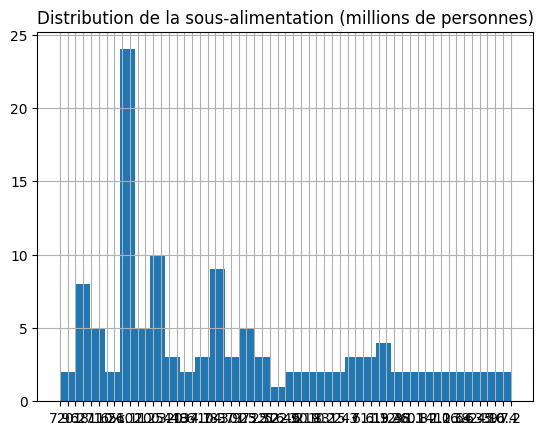

In [50]:
import matplotlib.pyplot as plt
dataset["sous_alimentation"].hist(bins=30)
plt.title("Distribution de la sous-alimentation (millions de personnes)")
plt.show()

In [51]:
print(dataset["sous_alimentation"].dtype)
print(dataset["sous_alimentation"].unique()[:20])

object
['7.9' '2.6' '0.2' '1.7' nan '8.1' '1.6' '1.5' '0.1' '26.1' '<0.1' '1'
 '2.2' '0.5' '0.4' '3.4' '2.8' '0.6' '137.7' '4.1']


In [52]:
dataset["sous_alimentation"] = dataset["sous_alimentation"].replace("<0.1", "0.05")
dataset["sous_alimentation"] = pd.to_numeric(dataset["sous_alimentation"], errors="coerce")

print(dataset["sous_alimentation"].dtype)
print(dataset["sous_alimentation"].describe())

float64
count    119.000000
mean       6.268487
std       23.719708
min        0.050000
25%        0.250000
50%        1.300000
75%        4.000000
max      216.300000
Name: sous_alimentation, dtype: float64


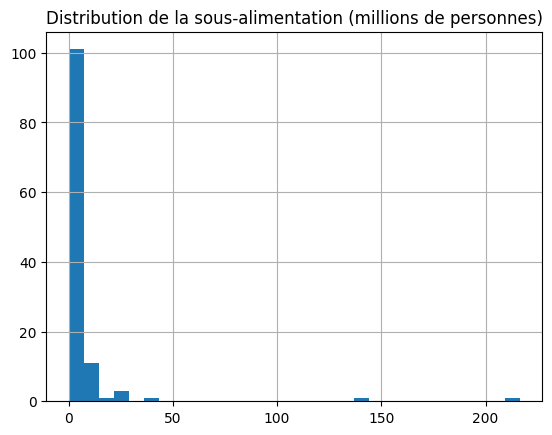

In [53]:
dataset["sous_alimentation"].hist(bins=30)
plt.title("Distribution de la sous-alimentation (millions de personnes)")
plt.show()

In [55]:
from scipy.stats import pearsonr
dataset["kcal_total"] = dataset["kcal_animaux"] + dataset["kcal_vegetaux"]

sous_valide = dataset.dropna(subset=["kcal_total", "sous_alimentation"])
r, p_value = pearsonr(sous_valide["kcal_total"], sous_valide["sous_alimentation"])
print("Coefficient de correlation (Pearson) :", round(r, 3))
print("p-value :", p_value)

Coefficient de correlation (Pearson) : -0.069
p-value : 0.4578773059135712


In [56]:
dataset["taux_sous_alimentation"] = (dataset["sous_alimentation"] * 1_000_000) / dataset["population"] * 100

sous_valide2 = dataset.dropna(subset=["kcal_total", "taux_sous_alimentation"])
r2, p_value2 = pearsonr(sous_valide2["kcal_total"], sous_valide2["taux_sous_alimentation"])
print("Coefficient de correlation (Pearson) :", round(r2, 3))
print("p-value :", p_value2)

Coefficient de correlation (Pearson) : -0.624
p-value : 3.5569546857325783e-14


In [57]:
dataset["cereales_par_habitant"] = (dataset["production_cereales"] * 1000) / dataset["population"]

sous_valide3 = dataset.dropna(subset=["cereales_par_habitant", "taux_sous_alimentation"])
r3, p_value3 = pearsonr(sous_valide3["cereales_par_habitant"], sous_valide3["taux_sous_alimentation"])
print("Coefficient de correlation (Pearson) :", round(r3, 3))
print("p-value :", p_value3)

Coefficient de correlation (Pearson) : -0.275
p-value : 0.0029214135455940928
